In [1]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv('premier-league-matches.csv')

print(df.head(),"\n\n")
print(df.shape,"\n\n")
print(df.dtypes,"\n\n")
print("Null values:", df.isnull().sum(),"\n\n")

   Season_End_Year  Wk        Date            Home  HomeGoals  AwayGoals  \
0             1993   1  1992-08-15   Coventry City          2          1   
1             1993   1  1992-08-15    Leeds United          2          1   
2             1993   1  1992-08-15   Sheffield Utd          2          1   
3             1993   1  1992-08-15  Crystal Palace          3          3   
4             1993   1  1992-08-15         Arsenal          2          4   

             Away FTR  
0   Middlesbrough   H  
1       Wimbledon   H  
2  Manchester Utd   H  
3       Blackburn   D  
4    Norwich City   A   


(12026, 8) 


Season_End_Year     int64
Wk                  int64
Date               object
Home               object
HomeGoals           int64
AwayGoals           int64
Away               object
FTR                object
dtype: object 


Null values: Season_End_Year    0
Wk                 0
Date               0
Home               0
HomeGoals          0
AwayGoals          0
Away              

## Exploratory Data Analysis

In [8]:
import matplotlib.pyplot as plt

### Understanding the target variable

In [11]:
df['result'] = df['FTR'].map({'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'})

print(df['result'].value_counts())

print(df['result'].value_counts(normalize=True).round(3))

result
Home Win    5519
Away Win    3410
Draw        3097
Name: count, dtype: int64
result
Home Win    0.459
Away Win    0.284
Draw        0.258
Name: proportion, dtype: float64


In [12]:
df.describe()

,Season_End_Year,Wk,HomeGoals,AwayGoals
count,12026.000000,12026.000000,12026.000000,12026.000000
mean,2007.713620,19.730501,1.524364,1.142525
std,9.072559,11.123916,1.306417,1.133930
min,1993.000000,1.000000,0.000000,0.000000
25%,2000.000000,10.000000,1.000000,0.000000
50%,2008.000000,20.000000,1.000000,1.000000
75%,2016.000000,29.000000,2.000000,2.000000
max,2023.000000,42.000000,9.000000,9.000000


### Finding feature correlations

In [15]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
le = LabelEncoder()

df['result_encoded'] = le.fit_transform(df['result'])

df.corr(numeric_only=True)['result_encoded'].sort_values()

AwayGoals         -0.624102
Season_End_Year   -0.028324
Wk                 0.016795
HomeGoals          0.619380
result_encoded     1.000000
Name: result_encoded, dtype: float64

### Data Visualization

Text(0.5, 1.0, 'Distribution of Home Goals')

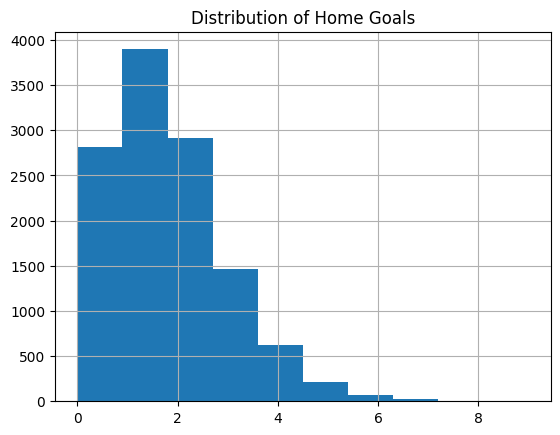

In [16]:
df['HomeGoals'].hist(bins=10)
plt.title("Distribution of Home Goals")

Text(0.5, 1.0, 'Distribution of Home Goals')

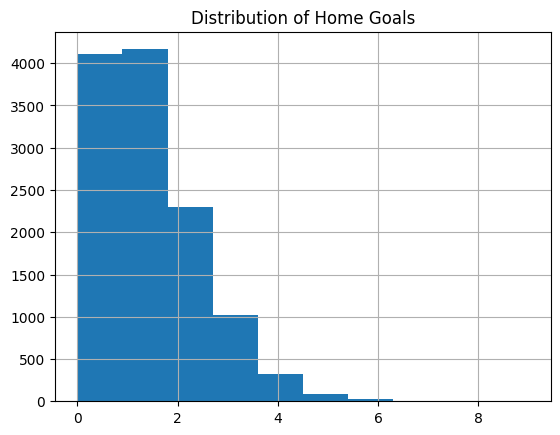

In [ ]:
df['AwayGoals'].hist(bins=10)
plt.title("Distribution of Away Goals")

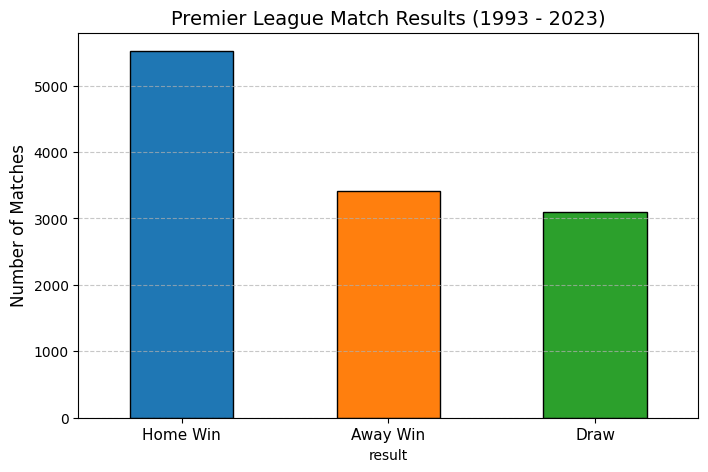

In [19]:
# Show total results
result_counts = df['result'].value_counts()
# Create a professional-looking bar chart
plt.figure(figsize=(8, 5))
result_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
plt.title("Premier League Match Results (1993 - 2023)", fontsize=14)
plt.ylabel("Number of Matches", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

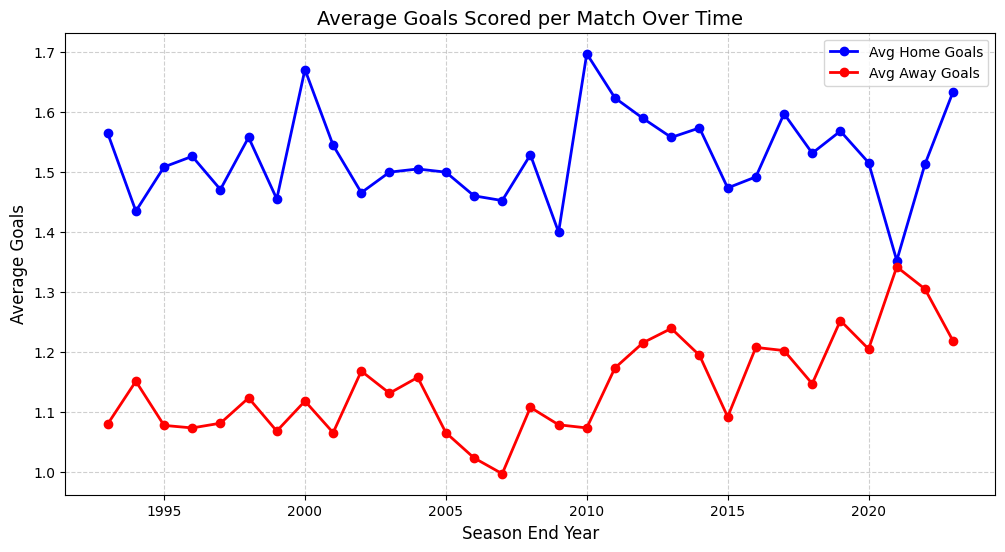

In [20]:
yearly_goals = df.groupby('Season_End_Year')[['HomeGoals', 'AwayGoals']].mean()

plt.figure(figsize=(12, 6))

plt.plot(yearly_goals.index, yearly_goals['HomeGoals'], marker='o', label='Avg Home Goals', color='blue', linewidth=2)
plt.plot(yearly_goals.index, yearly_goals['AwayGoals'], marker='o', label='Avg Away Goals', color='red', linewidth=2)
plt.title("Average Goals Scored per Match Over Time", fontsize=14)
plt.xlabel("Season End Year", fontsize=12)
plt.ylabel("Average Goals", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

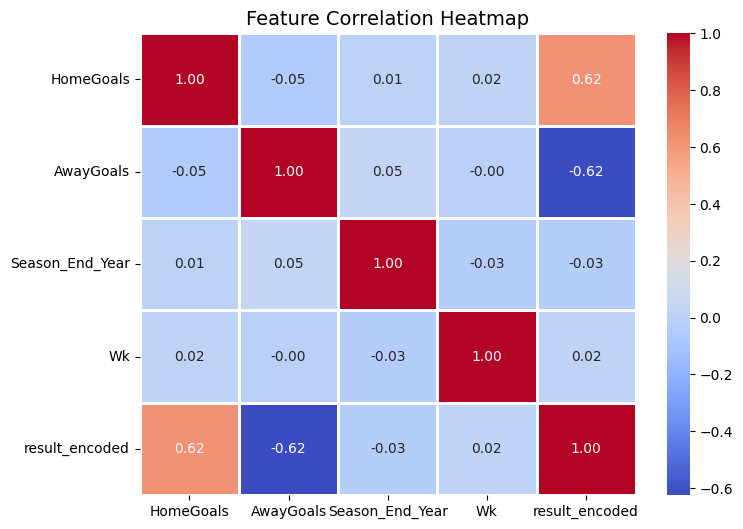

In [22]:
import seaborn as sns
numerical_df = df[['HomeGoals', 'AwayGoals', 'Season_End_Year', 'Wk', 'result_encoded']]
plt.figure(figsize=(8, 6))
# Create the heatmap
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

## Feature Encoding

In [26]:
df['date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


df['home_goals_avg'] = df.groupby('Home')['HomeGoals'].transform(
                            lambda x: x.shift(1).   # takes the entire list of goals and shifts them down one row. this allows the model to see historical data
                            rolling(5, min_periods=1).mean()    # moving average of last 5 matches.
                        )

df['away_goals_avg'] = df.groupby('Away')['AwayGoals'].transform(
                            lambda x: x.shift(1).   # takes the entire list of goals and shifts them down one row. this allows the model to see historical data
                            rolling(5, min_periods=1).mean()    # moving average of last 5 matches.
                        )

df['home_conceded_avg'] = df.groupby('Home')['AwayGoals'].transform(
                            lambda x: x.shift(1).   # takes the entire list of goals and shifts them down one row. this allows the model to see historical data
                            rolling(5, min_periods=1).mean()    # moving average of last 5 matches.
                        )

df['away_conceded_avg'] = df.groupby('Away')['HomeGoals'].transform(
                            lambda x: x.shift(1).   # takes the entire list of goals and shifts them down one row. this allows the model to see historical data
                            rolling(5, min_periods=1).mean()    # moving average of last 5 matches.
                        )


In [29]:
df = df.dropna()

le_home = LabelEncoder()
le_away = LabelEncoder()
le_result = LabelEncoder()


df['home_encoded'] = le_home.fit_transform(df['Home'])
df['away_encoded'] = le_home.fit_transform(df['Away'])
df['result_encoded'] = le_home.fit_transform(df['result'])

/tmp/ipykernel_746351/3043463265.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['home_encoded'] = le_home.fit_transform(df['Home'])
/tmp/ipykernel_746351/3043463265.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['away_encoded'] = le_home.fit_transform(df['Away'])
/tmp/ipykernel_746351/3043463265.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

### Splitting the Data

In [30]:
from sklearn.model_selection import train_test_split

features = ['home_encoded', 'away_encoded', 'home_goals_avg', 'away_goals_avg', 'home_conceded_avg', 'away_conceded_avg']

X = df[features]
y = df['result_encoded']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100)

model.fit(X_train, y_train)

/home/dev/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
predictions = model.predict(X_test)

le_result.fit(df['result']) 

preds_labels = le_result.inverse_transform(predictions[:10])
print(preds_labels)

['Away Win' 'Home Win' 'Home Win' 'Home Win' 'Home Win' 'Home Win'
 'Home Win' 'Home Win' 'Home Win' 'Away Win']


## Evaluation Metrics

In [38]:
from sklearn.metrics import *
print(classification_report(y_test, predictions, target_names=le_result.classes_))

print(accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

    Away Win       0.43      0.31      0.36       654
        Draw       0.00      0.00      0.00       628
    Home Win       0.51      0.87      0.64      1108

    accuracy                           0.49      2390
   macro avg       0.31      0.40      0.34      2390
weighted avg       0.35      0.49      0.40      2390

0.4916317991631799


/home/dev/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dev/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dev/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
